# Diabetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import datasets
import seaborn as sns

### Objetivos

 1. Exploración del dataset (EDA)
    - Distribución de la variable objetivo (y)
          - ¿Tiene una distribución normal, sesgada o con outliers?
    - Distribución de cada feature
          - ¿Qué variables están más dispersas o más concentradas?
    - Correlaciones entre las variables
          - ¿Hay alguna variable altamente correlacionada con la variable objetivo?
          - ¿Existen multicolinealidades entre las características?
    - Visualización
          - Histogramas, pares de gráficos (pairplots), matriz de correlación (heatmap), boxplots.

2. Modelado y predicción
   - Regresión Lineal
   - Ridge Regression (regularización L2)
   - Lasso Regression (regularización L1)
   - Árboles de decisión, Random Forest, Gradient Boosting
   - SVR (Regresión con máquinas de soporte vectorial)
   - Redes neuronales simples
   - Métricas de evaluación:
     - MSE (Mean Squared Error)
     - RMSE (Root MSE)
     - MAE (Mean Absolute Error)
     - R² (coeficiente de determinación)

Puedes comparar estas métricas entre modelos para determinar cuál se desempeña mejor.

3. Análisis de importancia de variables
   - Coeficientes del modelo lineal
         - ¿Qué variables tienen mayor peso en la predicción?
   - Importancia de características (feature importance)
         - Para modelos como Random Forest o Gradient Boosting.
   - Regularización (Ridge/Lasso)
         - ¿Qué variables se descartan cuando aplicas Lasso?

4. Validación cruzada
   - Utiliza K-Fold Cross Validation (usualmente k=5 o k=10)

Esto evita que tus resultados dependan de una sola partición de entrenamiento/test.

5. Evaluación estadística
   - Prueba la normalidad de los residuos (p. ej. prueba de Shapiro-Wilk)
   - Verifica homocedasticidad (igual varianza en los errores)
   - Revisa outliers o puntos influyentes (como la distancia de Cook)

### Introducción a este dataset.

* Contiene información de pacientes con diabetes y su propósito principal es predecir una medida continua relacionada con la progresión de la enfermedad, un año después de la medición inicial.
* Número de muestras: 442.
* Objetivo (`target`): una medida cuantitativa de la progresión de la enfermedad un año después del diagnóstico (valor continuo).
* Las características son:
  1. Edad
  2. Sexo
  3. Índice de masa corporal (IMC)
  4. Presión arterial promedio
  5. 6 medidas sanguíneas (como niveles de insulina, azúcar, etc.)
* Este dataset por si solo es un un diccionario con las siguientes keys:
  1. ***'data'***: Cada fila representa un paciente (una muestra). Cada columna representa una característica medida para ese paciente (por ejemplo: edad, sexo, IMC, etc.)
  2. ***'target'***: Es el valor que queremos predecir. En este caso, es una medida continua de la progresión de la diabetes, estimada un año después del registro de las características.
  3. ***'frame'***:
  4. ***'DESCR'***: Acerca del conjunto de dataset.
  5. ***'feature_names'***: nombre de todas las columnas medidas que nos dieron.
  6. ***'data_filename'***: nombre del archivo con todos los datos
  7. ***'target_filename'***: nombre del archivo esperado.
  8. ***'data_module'***: nombre al modulo al que pertenencen los datos.

In [2]:
# Cargamos el primer conjunto de llaves
diabetes = datasets.load_diabetes(as_frame=True)
# Imprimimos
print(diabetes.keys())
print("\n Descripcion:", diabetes["DESCR"])
print("\n Caracteristicas:", diabetes["feature_names"])
print("\n Caracteristicas:", diabetes["data_filename"])

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

 Descripcion: .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg

### Obtención de Datos.

* Estos datos ya se encuentran escalados.
* Attribute Information:
    - age:     Edad en años.
    - sex:     Genero de la persona.
    - bmi:     IMC
    - bp:      Promedio Presión Sanguinea
    - s1:      Nivel de colesterol total en sangre.
    - s2:      Nivel de colesterol LDL (lipoproteína de baja densidad).
    - s3:      Nivel de colesterol HDL (lipoproteína de alta densidad).
    - s4:      Nivel total de triglicéridos en sangre.
    - s5:      Nivel de glucosa en sangre (similar a una prueba de azúcar).
    - s6:      Medida de respuesta de insulina.

In [3]:
data, esperados = diabetes.data, diabetes.target
df = pd.DataFrame(data, columns=diabetes.feature_names)
df = pd.concat([data, esperados], axis=1)
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [32]:
#print(df.info())
#print(df.describe())

### 1. Distribuciones de los datos

* Parece que la Edad si sigue una distribución normal, pero ligeramente hacía la derecha, esto se debe por la media.
* Sexo no sigue una distribución normal, ya que solo hay 2 valores. Hombre, Mujer.
* IMC y Presión Sanguinea sigue una distribución normal un poco hacia la izquierda.
* Solo S4 parece que no siguiera una distribución normal.
* `.flatten()`: Cuando creas una cuadrícula de subgráficos con plt.subplots(6, 2), axes es un arreglo 2D de objetos AxesSubplot, con forma (6, 2) (6 filas × 2 columnas). Esto significa que para acceder a un subplot necesitas usar dos índices: axes[0, 0], axes[5, 1], etc.

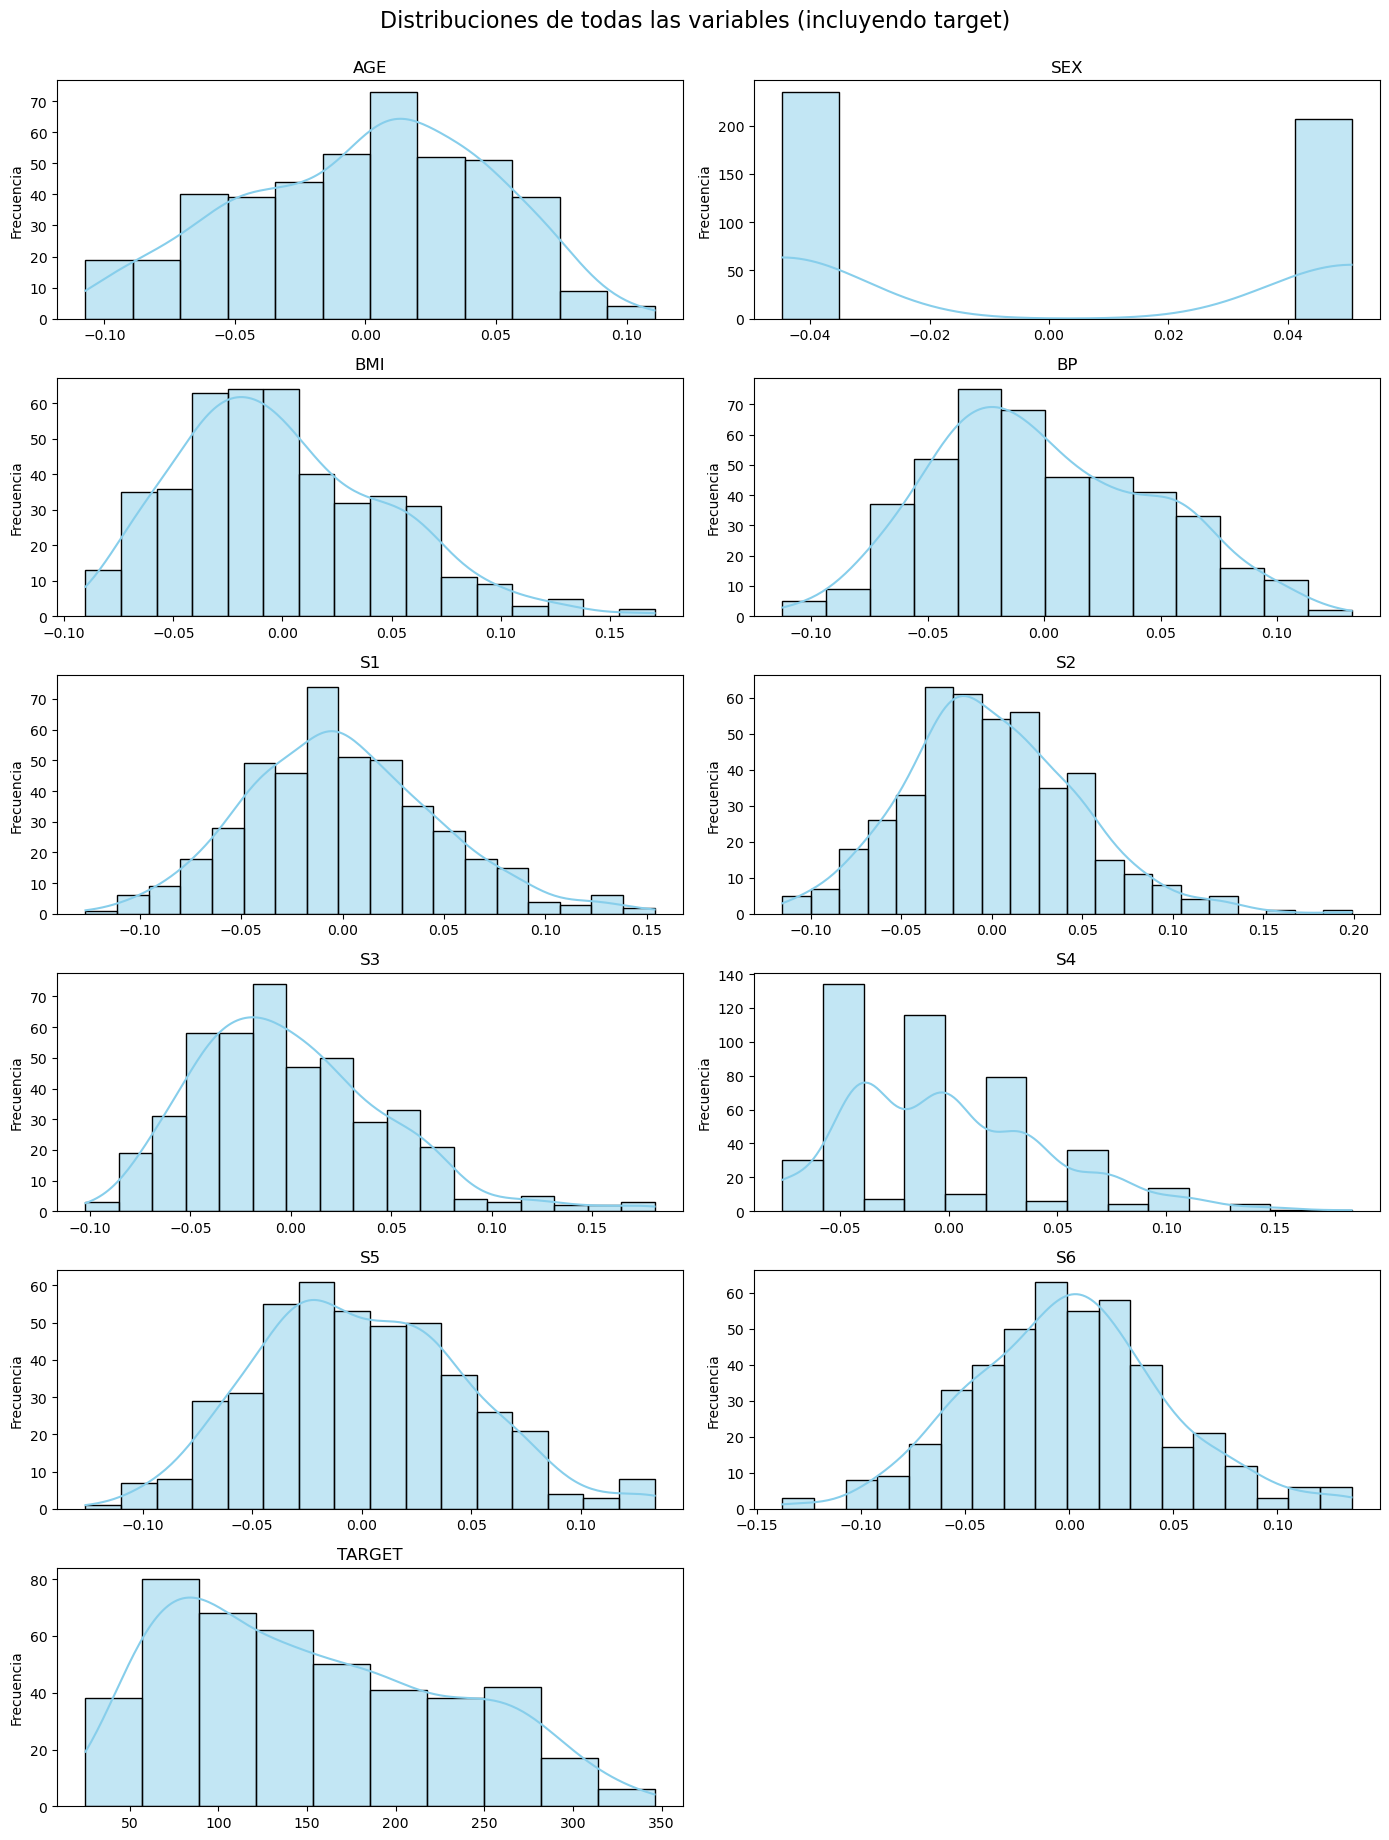

In [4]:
# Crear figura con 6x2 subplots para las 11 columnas
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

# Dibujar todas las distribuciones
for idx, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[idx], color="skyblue")
    axes[idx].set_title(column.upper())
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Frecuencia")

# Eliminar subplot extra (último será vacío si hay 12 subplots y solo 11 columnas)
if len(df.columns) < len(axes):
    for j in range(len(df.columns), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distribuciones de todas las variables (incluyendo target)", fontsize=16, y=1.02)
plt.show()

### 1. Matriz de Correlaciones

* Parece que hay una relación entre s1: Nivel de colesterol total en sangre y s2: Nivel de colesterol LDL (lipoproteína de baja densidad).
* Parece que hay una relación entre s3: Nivel de colesterol HDL (lipoproteína de alta densidad) y s4: Nivel total de triglicéridos en sangre.

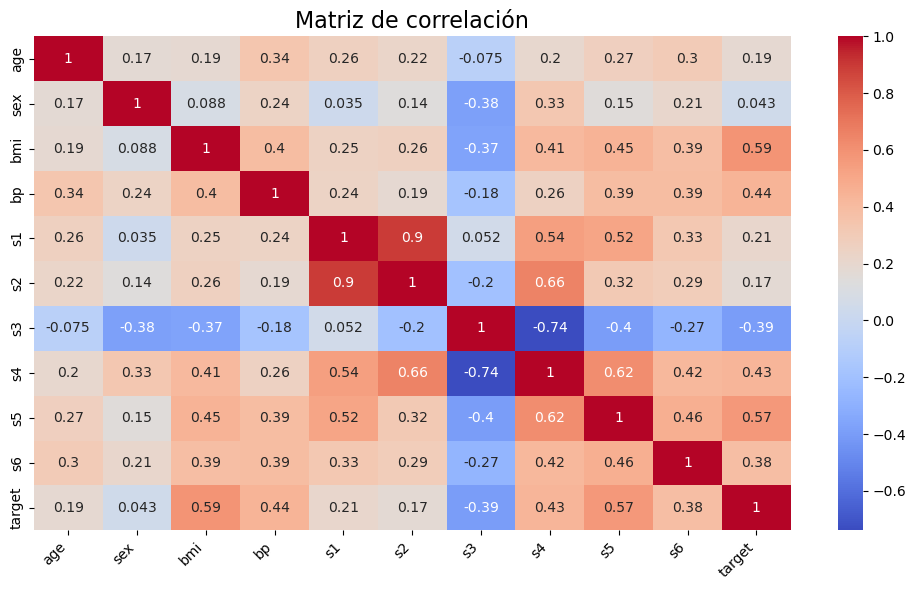

In [41]:
#Usando sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", xticklabels=True, yticklabels=True)
plt.title("Matriz de correlación", fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rota etiquetas para mayor claridad
plt.tight_layout()
plt.show()
# matriz = df.corr()
# plt.matshow(matriz, cmap="bwr", vmin=-1, vmax=1)

# # ponemos las columnas
# plt.xticks(range(11), df.columns, rotation=90)
# plt.yticks(range(11), df.columns)

# # Imprimos el contenido de cada casilla
# for i in range(len(matriz.columns)):
#     for j in range(len(matriz.columns)):
#         plt.text(i,j, round(matriz.iloc[i,j],2), ha="center", va="center")

# plt.colorbar()
# plt.show()

### 1. Gráficas de Dispersión.

* Gráfiquemos solo las que nos interesan,es decir las que se ven que tienen una correlación.

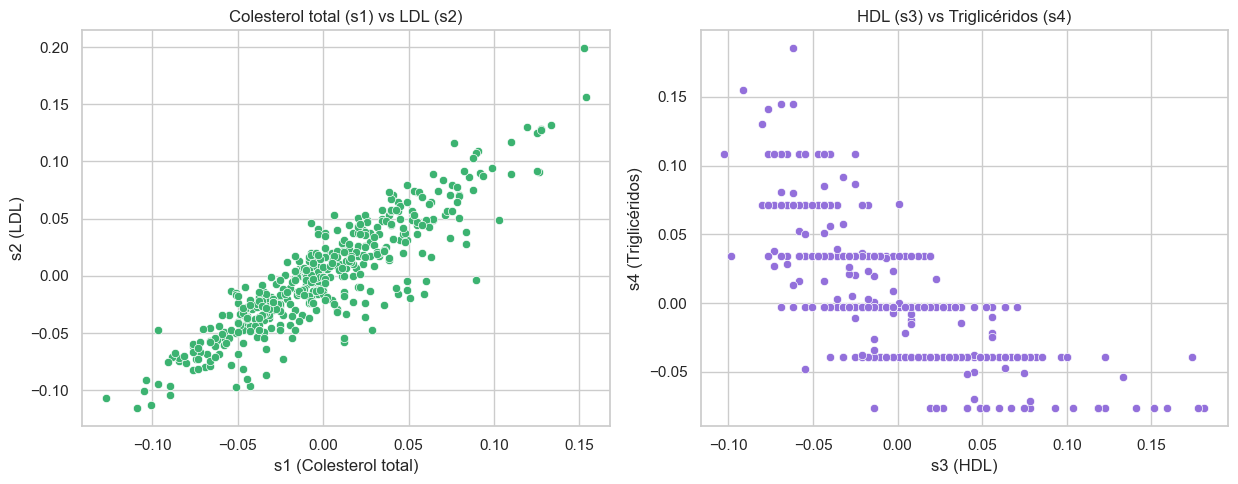

In [44]:
# Configurar estilo
sns.set(style="whitegrid")
plt.figure(figsize=(18, 5))

# 2. s1 (Colesterol total) vs s2 (Colesterol LDL)
plt.subplot(1, 3, 2)
sns.scatterplot(x='s1', y='s2', data=df, color='mediumseagreen')
plt.title('Colesterol total (s1) vs LDL (s2)')
plt.xlabel('s1 (Colesterol total)')
plt.ylabel('s2 (LDL)')

# 3. s3 (HDL) vs s4 (Triglicéridos)
plt.subplot(1, 3, 3)
sns.scatterplot(x='s3', y='s4', data=df, color='mediumpurple')
plt.title('HDL (s3) vs Triglicéridos (s4)')
plt.xlabel('s3 (HDL)')
plt.ylabel('s4 (Triglicéridos)')

plt.tight_layout()
plt.show()

* Realmente no fueron necesarias, ya que ya habíamos sacado la matriz de correlaciones.
* Pero para compararlo con el target, quizas si es necesario.

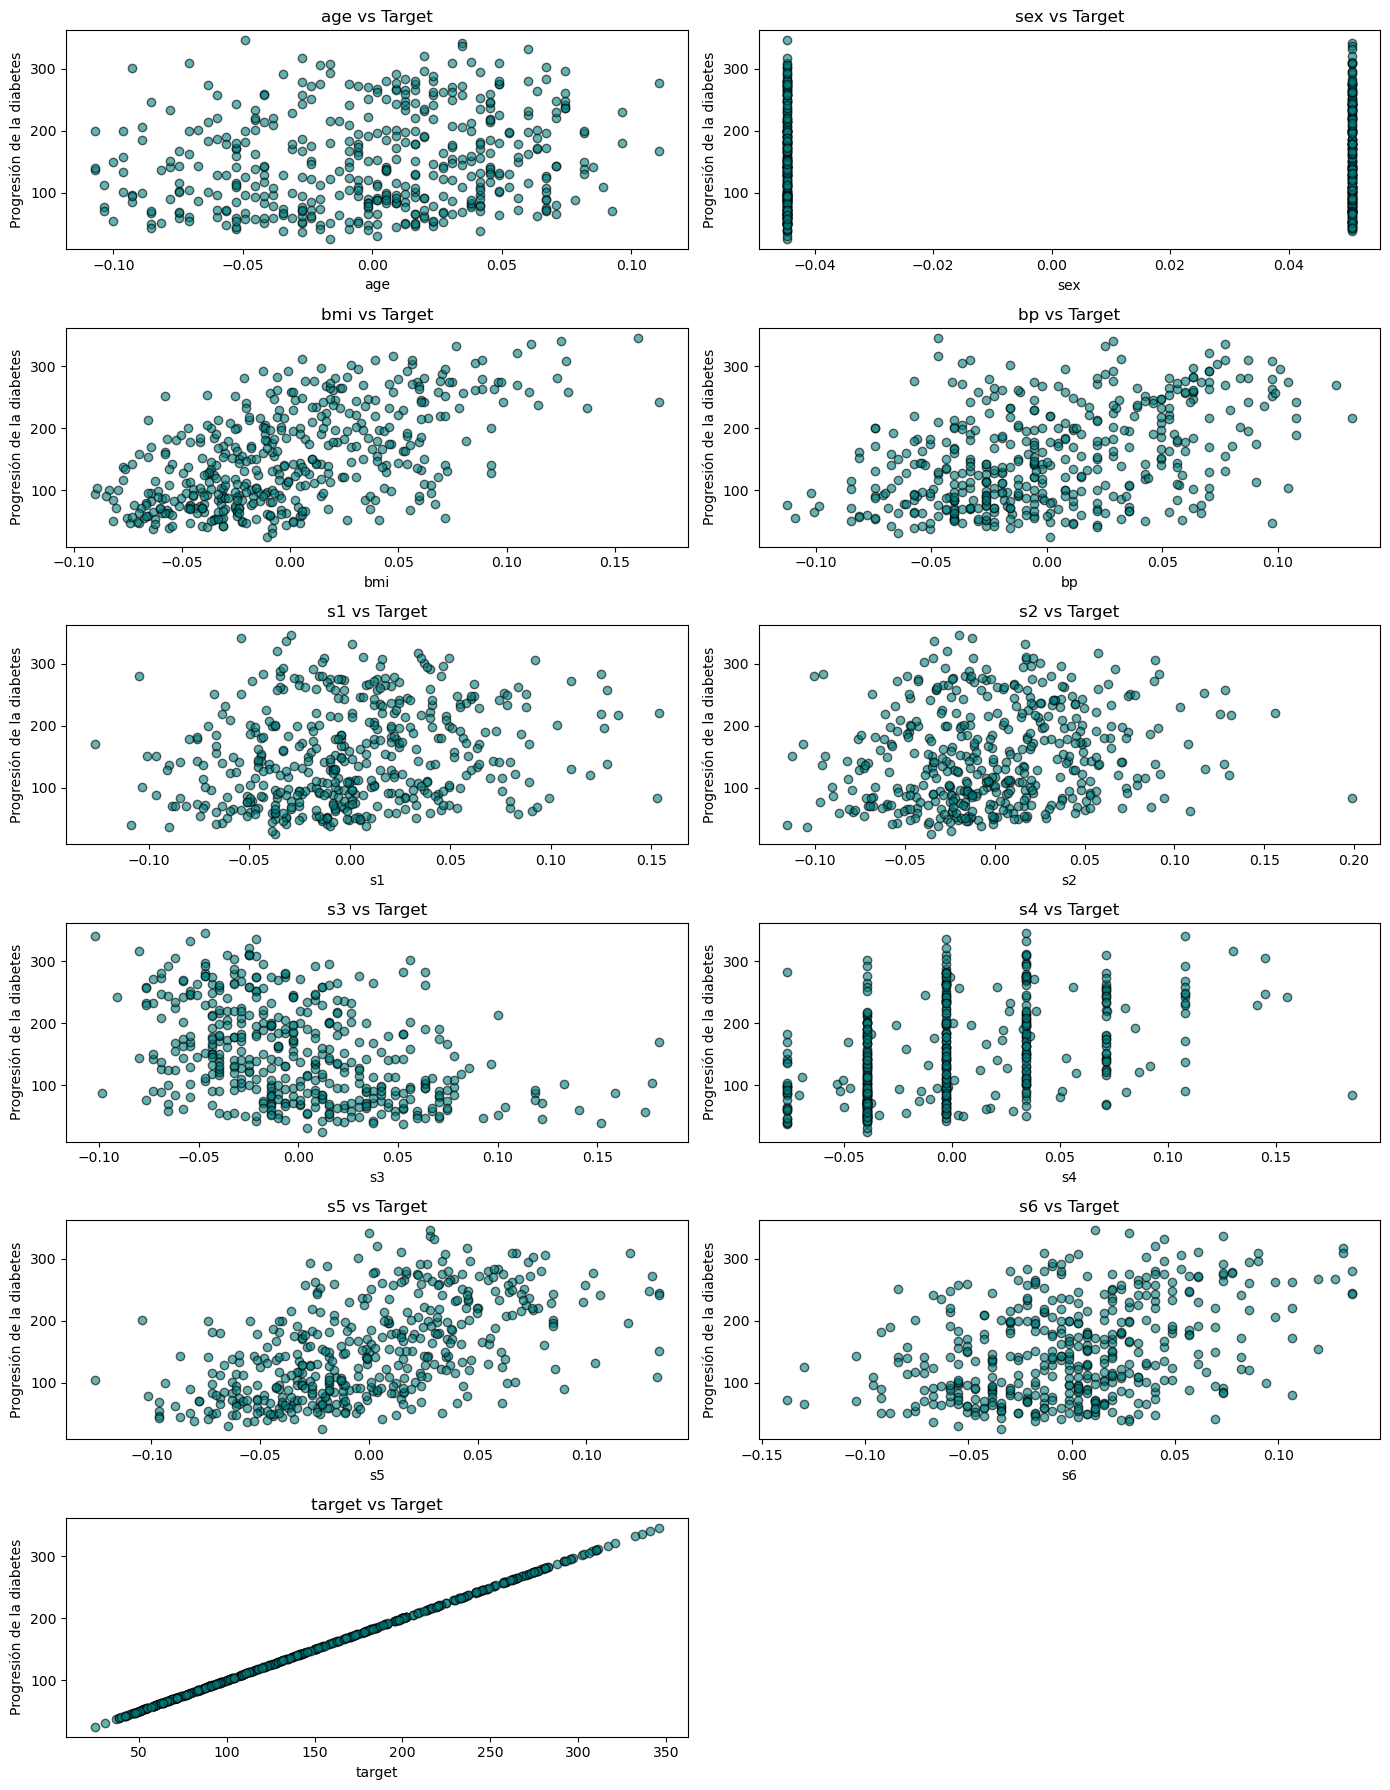

In [14]:
# Crear figura con subplots
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

# Generar scatterplots
for i, col in enumerate(df.columns):
    axes[i].scatter(df[col], df["target"], alpha=0.6, color='teal', edgecolor='black')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Progresión de la diabetes')
    axes[i].set_title(f'{col} vs Target')

# Eliminar subplot extra (último será vacío si hay 12 subplots y solo 11 columnas)
if len(df.columns) < len(axes):
    for j in range(len(df.columns), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 1. BloxPlots

* Realmente las unicas gráficas sin dataoutliers son Edad, Presión Sanguinea y target.

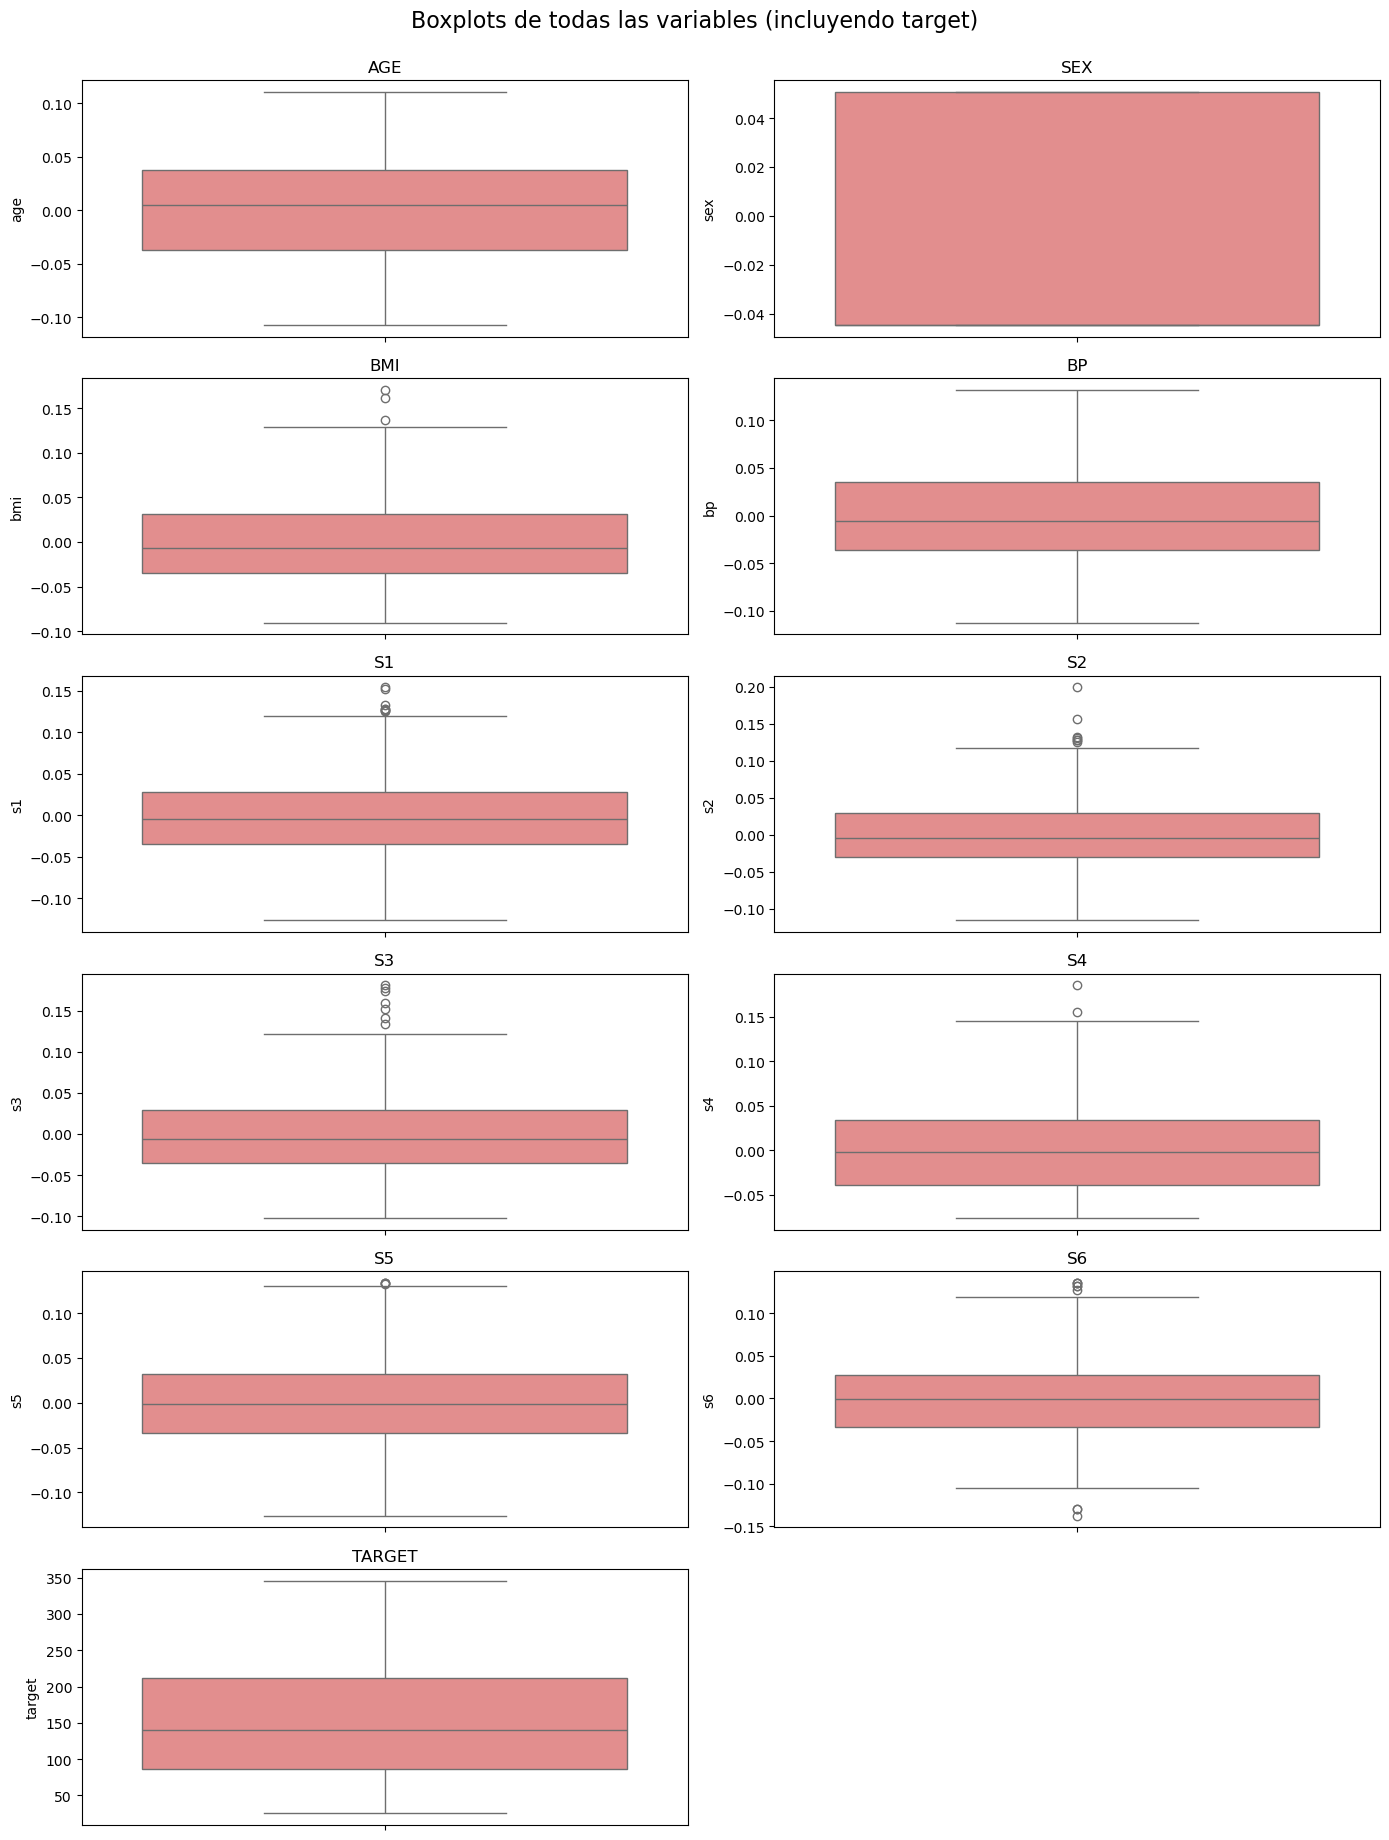

In [15]:
# Crear figura con 6x2 subplots para las 11 columnas
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

# Dibujar boxplots
for idx, column in enumerate(df.columns):
    sns.boxplot(y=df[column], ax=axes[idx], color="lightcoral")
    axes[idx].set_title(column.upper())
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel(column)

# Eliminar subplot extra si hay menos columnas que subplots
if len(df.columns) < len(axes):
    for j in range(len(df.columns), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Boxplots de todas las variables (incluyendo target)", fontsize=16, y=1.02)
plt.show()

### 1.Conclusiones

1. ¿Tiene una distribución normal, sesgada o con outliers?
   * Las variables que siguen una distribucion normal son: Edad, S1, S2, S3, S4 y el S6.
   * Las únicas variables sin data outliers son: Edad, Presión Sanguinea y target.
2. Correlaciones entre las variables.
   * Parece que hay una correlación positiva entre s1 y s2.
   * Parece que hay una correlación negativa entre s3 y s4.
3. ¿Hay alguna variable altamente correlacionada con la variable objetivo?
   * No se encontró ninguna variable que este correlacionada con "target".

### 2. División del dataset

* Esto es crucial para evaluar el rendimiento de tu modelo en datos nunca antes vistos, evitando así el sobreajuste (overfitting).
* Dividirás tus datos en:
  * 80% para entrenamiento (X_train, y_train)
  * 20% para prueba (X_test, y_test)
  * Esto se hace con la función `train_test_split` de `sklearn.model_selection`.
* `test_size=0.2` → 20% de los datos se reservan para prueba.
* `random_state=42` → Asegura que la división sea reproducible cada vez que ejecutes el código.
* `X_train`, `y_train` → se usarán para entrenar el modelo.
* `X_test`, `y_test` → se usarán para evaluar el rendimiento del modelo.

In [7]:
from sklearn.model_selection import train_test_split

x = diabetes["data"]
y = diabetes["target"]

# División en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Verifica las formas de los datos
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (353, 10)
Tamaño del conjunto de prueba: (89, 10)


### 3. Elección de un modelo de regresión

* Objetivo: Entrenar un modelo que prediga el valor de target (progresión de la diabetes) usando las 10 variables clínicas como entrada.

In [9]:
from sklearn.linear_model import LinearRegression

# Crear una instancia del modelo
model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Predecir con el modelo ya entrenado
y_pred = model.predict(X_test)

### 3. Evaluar el modelo con métricas básicas

* Usaremos Error Cuadrático Medio (***MSE***) y Coeficiente de Determinación (***R²***).
* MSE: Cuanto más bajo, mejor. Te dice cuánto se equivocó el modelo, en promedio, al predecir el target.
* R²: Varía de 0 a 1 (incluso puede ser negativo). Un valor cercano a 1 indica que el modelo explica bien la variabilidad del `target`.
* Po ejemplo: R² de 0.5 significa que el modelo explica el 50% de la variación de la progresión de la enfermedad.
* No, no son malos, pero tampoco son excelentes. En el contexto de este dataset y un modelo tan simple como regresión lineal sin ajustes, un R² de 0.45 es razonable.
* La regresión lineal está explicando alrededor del 45% de la variabilidad del target.
* Este valor es muy similar al que obtienen muchos notebooks o libros cuando aplican regresión lineal sobre este dataset sin ajustar hiperparámetros ni aplicar técnicas más avanzadas.
* El dataset de diabetes de scikit-learn ya viene bastante limpio y estandarizado, así que no necesitas escalarlo ni normalizarlo más para regresión lineal.
* Entonces, tus resultados no son malos por saltarte el preprocesamiento, sino porque:
  * Estás usando un modelo básico (regresión lineal sin regularización).
  * No has ajustado hiperparámetros.
  * No has hecho selección de características ni combinado modelos.

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE (Error cuadrático medio):", mse)
print("R² (Coeficiente de determinación):", r2)

MSE (Error cuadrático medio): 2900.1936284934804
R² (Coeficiente de determinación): 0.4526027629719196


* Regularización Ridge o Lasso Regression Evita sobreajuste y puede mejorar rendimiento.

In [11]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("R² con Ridge:", ridge.score(X_test, y_test))

R² con Ridge: 0.41915292635986545


### 4. Evaluación del modelo

* Ya calculaste estas métricas: MSE: 2900 y R²: 0.45.
* Ahora vamos a visualizar qué tan bien predice el modelo, lo que ayuda mucho a interpretar ese R².
* La línea roja es la línea ideal donde las predicciones serían perfectas.
* Cuanto más cerca estén los puntos a esa línea, mejor está prediciendo el modelo.
* Dispersión grande = errores mayores.
* Recordemos que:
  * `y_pred = model.predict(X_test)`: es la predección a partir del modelo partir de la x.
  * `y_test`: son los datos geniunos de la muestra del 20%
  * `y_test` corresponde a nuestro X, y `y_pred` al eje Y.
  * `alpha=0.6` → Hace que los puntos sean semitransparentes, para ver mejor cuando se superponen.
* Para el plot, lo que estamos haciendo es graficar 2 puntos y conectarlos con una recta.
* Se conecta el punto minimo (x,y) y se conecta con el máximo (x,y)
* Imagina que quieres dibujar una línea diagonal perfecta en un gráfico XY — es decir, una línea que vaya de la esquina inferior izquierda a la superior derecha. Esa línea sigue la ecuación: `y=x`.
* Por tanto, si y_test.min() = 50 y y_test.max() = 300, al poner: `plt.plot([50, 300], [50, 300])` → (50,50), (300,300)
* Sin el otro par, estás dando solo los valores de X — pero no das los valores de Y, y matplotlib no sabría qué línea trazar (o usaría el índice como Y).

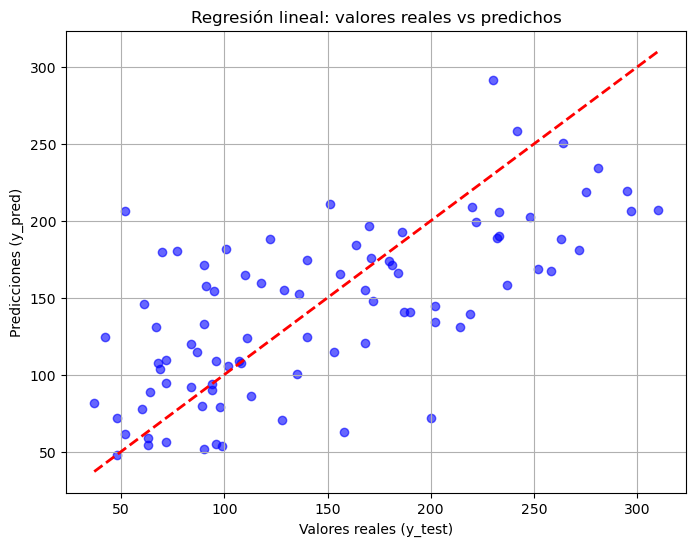

In [15]:
plt.figure(figsize=(8, 6))

# 2 Figuras
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
# Asignamos valores de X y Y.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Valores reales (y_test)')
plt.ylabel('Predicciones (y_pred)')
plt.title('Regresión lineal: valores reales vs predichos')

plt.grid(True)
plt.show()

### 5. Interpretación del modelo (coeficientes)

* Ahora vamos a ver qué variables clínicas tienen más impacto en la predicción, según el modelo de regresión lineal que entrenaste.
* La regresión lineal te da una fórmula del tipo: `target ≈ coef_1 * X1 + coef_2 * X2 + ... + intercepto`
* Los coeficientes (coef_) te dicen cuánto cambia el valor del target cuando una variable cambia, manteniendo las demás constantes.
  * Coeficiente positivo → la variable aumenta la progresión.
  * Coeficiente negativo → la variable disminuye la progresión.
  * Coeficiente más grande (en valor absoluto) → mayor impacto.
* Las variables con coeficientes grandes (en valor absoluto) son las más influyentes.
* `bmi` (índice de masa corporal) tiene el coeficiente más alto.
* `s5` (glucosa o insulina) también tiene impacto notable.
* Variables como `sex` o `s3` pueden tener un coeficiente negativo.
* Esto confirma lo que veías antes: `IMC` y `glucosa` son factores importantes en la progresión de la diabetes.
* Cada barra representa una variable del dataset.
* Cuanto más larga, más fuerte es su efecto en la predicción.
* Si la barra está hacia la derecha (positivo): la variable aumenta el valor del target.
* Si está hacia la izquierda (negativo): la variable reduce el valor del target.

  Variable  Coeficiente
4       s1  -931.488846
8       s5   736.198859
2      bmi   542.428759
5       s2   518.062277
3       bp   347.703844
7       s4   275.317902
1      sex  -241.964362
6       s3   163.419983
9       s6    48.670657
0      age    37.904021


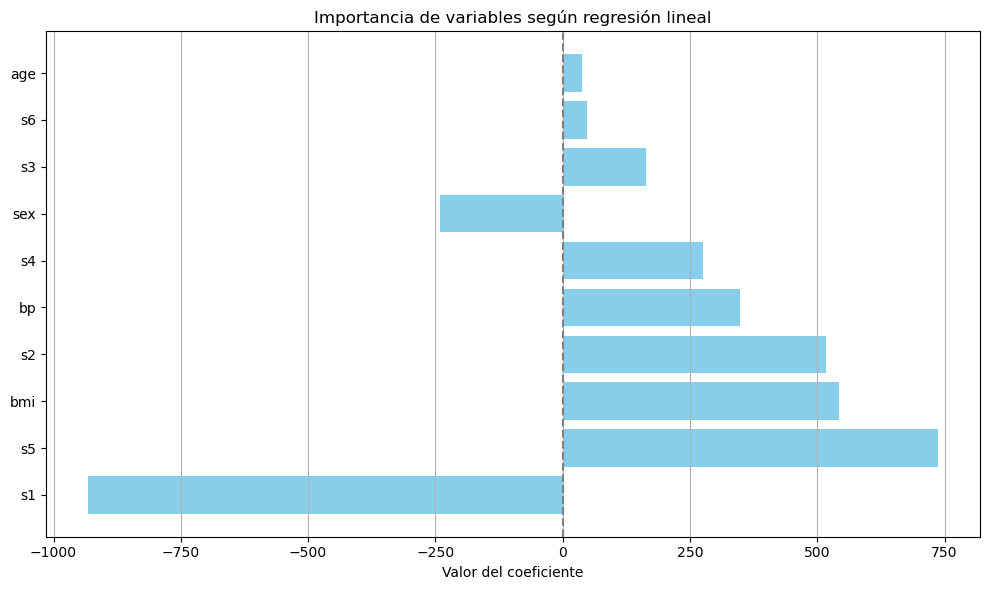

In [18]:
# Obtener los coeficientes del modelo
coef = model.coef_

# Nombres de las variables (features)
feature_names = diabetes.feature_names

# Crear un DataFrame ordenado
coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coef
}).sort_values(by='Coeficiente', key=np.abs, ascending=False)

print(coef_df)
# Graficar
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color='skyblue')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title('Importancia de variables según regresión lineal')
plt.xlabel('Valor del coeficiente')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### 6. Modelos más avanzados

* 1.- Ridge Regression (Regresión con regularización L2).
  * Penaliza los coeficientes grandes → ayuda a reducir el sobreajuste.
  * Muy útil cuando hay multicolinealidad entre variables.
* 2.- Lasso Regression (Regresión con regularización L1).
  * También penaliza coeficientes grandes.
  * Además, puede eliminar variables irrelevantes (coeficiente = 0).
  * Útil para selección automática de variables.

* ¿Cómo saber si mejoró?
  * Compara los valores de R² con el modelo de regresión lineal original (~0.45).
  * Valores más altos → mejor ajuste.
  * Observa si alguno reduce el error (MSE) sin perder capacidad de generalización.

***Interpretación***
*  Lasso Regression es el mejor de los tres modelos en tu caso:
  * Tiene el R² más alto (0.47) → explica más variación del target.
  * Tiene el MSE más bajo → comete menos error promedio al predecir.
* Ridge Regression no mejora respecto al modelo lineal. De hecho, empeora ligeramente (MSE mayor, R² menor). Esto puede deberse a:
  * La regularización está suavizando demasiado los coeficientes.
  * El valor de alpha=1.0 quizá no sea óptimo (puedes ajustar con GridSearch).
* El modelo lineal base sigue siendo razonable, pero Lasso lo supera ligeramente sin mayor complejidad.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("📘 Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

print("📙 Lasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R²:", r2_score(y_test, y_pred_lasso))

📘 Ridge Regression
MSE: 3077.41593882723
R²: 0.41915292635986545
📙 Lasso Regression
MSE: 2798.1934851697188
R²: 0.4718547867276227


* Puedes hacer una tabla comparativa si quieres algo así

In [21]:
results = {
    'Modelo': ['Lineal', 'Ridge', 'Lasso'],
    'R²': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ]
}
print(pd.DataFrame(results))

   Modelo        R²          MSE
0  Lineal  0.452603  2900.193628
1   Ridge  0.419153  3077.415939
2   Lasso  0.471855  2798.193485


### 7. Validación cruzada

* La validación cruzada te permite evaluar el rendimiento de un modelo de forma más robusta, usando diferentes particiones del dataset.
* El dataset se divide en k “folds” (partes).
* El modelo se entrena en k-1 partes y se evalúa en la parte restante.
* Esto se repite k veces, cambiando la parte usada para prueba.
* Se calcula el promedio del rendimiento.
* Usaremos: 5-fold cross-validation con regresión lineal, Ridge y Lasso.
* ¿Qué obtienes?
  * ***RMSE promedio*** → error típico del modelo al predecir.
  * ***Desviación estándar*** → qué tan variable es ese error entre particiones.
  * Si un modelo tiene bajo RMSE y baja desviación, es estable y generaliza bien.

In [23]:
from sklearn.model_selection import cross_val_score

# Usaremos MSE negativo porque sklearn así lo devuelve por convención
def evaluar_modelo(modelo, nombre):
    scores = cross_val_score(modelo, x, y, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f" {nombre}")
    print(f"RMSE (promedio): {rmse_scores.mean():.2f}")
    print(f"RMSE (desviación estándar): {rmse_scores.std():.2f}\n")

# Modelos
evaluar_modelo(LinearRegression(), "Regresión Lineal")
evaluar_modelo(Ridge(alpha=1.0), "Ridge Regression")
evaluar_modelo(Lasso(alpha=0.1), "Lasso Regression")

 Regresión Lineal
RMSE (promedio): 54.69
RMSE (desviación estándar): 1.37

 Ridge Regression
RMSE (promedio): 58.45
RMSE (desviación estándar): 2.00

 Lasso Regression
RMSE (promedio): 54.84
RMSE (desviación estándar): 1.07



### 8. Guardar el modelo entrenado

* Usaremos la librería joblib, que es muy eficiente para guardar objetos grandes como modelos de machine learning.

In [24]:
import joblib

# Guardar el modelo Lasso en un archivo
joblib.dump(lasso, 'modelo_lasso.pkl')
print("Modelo guardado como 'modelo_lasso.pkl'")

# Cargar el modelo desde el archivo
modelo_cargado = joblib.load('modelo_lasso.pkl')

# Usarlo para predecir
y_pred_cargado = modelo_cargado.predict(X_test)

Modelo guardado como 'modelo_lasso.pkl'
